#Automating Text Vectorization

In [1]:
#Import required librairies
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Embedding,LSTM,GRU
from tensorflow.keras.layers import TextVectorization, InputLayer
import tensorflow as tf

In [2]:
max_words = 10000
max_length = 500

model = Sequential()
model.add(InputLayer(shape=(1,), dtype=tf.string))
model.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model.add(Embedding(max_words, 32))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,048,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,368,257 (9.03 MB)

 Trainable params: 2,368,257 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/reviews.csv', encoding="ISO-8859-1")
df = df.sample(frac=1, random_state=0)
df.head()

,Text,Sentiment
11841,Al Pacino was once an actor capable of making ...,0
19602,After Chaplin made one of his best films: Doug...,0
45519,This movie is sort of a Carrie meets Heavy Met...,1
25747,I have fond memories of watching this visually...,1
42642,"In the '70s, Charlton Heston starred in sci-fi...",1


In [4]:
#Remove duplicate rows
df=df.drop_duplicates()

In [5]:
df.groupby("Sentiment").describe()

Text                                                            \
           count unique                                                top   
Sentiment                                                                    
0          24697  24697  What could've been a great film about the late...   
1          24884  24884  I really enjoyed this film. All aspects of the...   

                
          freq  
Sentiment       
0            1  
1            1

In [6]:
#Split the dataset
x=df["Text"]
y=df["Sentiment"]
model.layers[0].adapt(x)

In [7]:
hist = model.fit(tf.constant(x), y, validation_split=0.5, epochs=5, batch_size=250)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 231ms/step - accuracy: 0.6110 - loss: 0.6437 - val_accuracy: 0.7835 - val_loss: 0.4567
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - accuracy: 0.8699 - loss: 0.3075 - val_accuracy: 0.8552 - val_loss: 0.3303
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.9422 - loss: 0.1638 - val_accuracy: 0.8748 - val_loss: 0.3104
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - accuracy: 0.9781 - loss: 0.0737 - val_accuracy: 0.8586 - val_loss: 0.3800
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.9956 - loss: 0.0256 - val_accuracy: 0.8623 - val_loss: 0.4291


[]

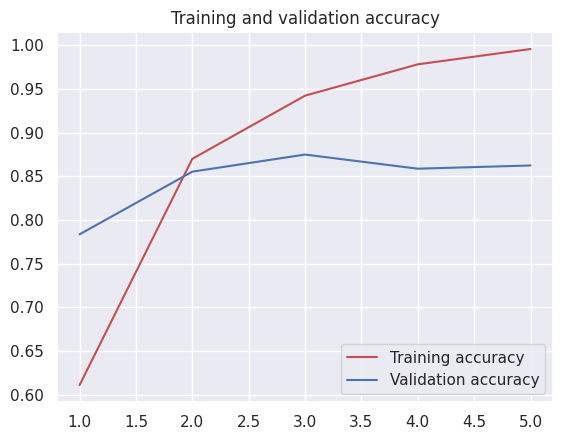

In [8]:
from numpy import e
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

acc=hist.history['accuracy']
val_acc=hist.history['val_accuracy']
epochs=range(1, len(acc)+1)

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.plot()

In [9]:
#Make a prediction
text="Excellent foof and fantastic service"
model.predict(tf.constant([text]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


np.float32(0.9516523)

In [10]:
model.save("sentiment_model.keras")           # saves as a folder


#LSTM for Text classification

In [11]:
max_words = 10000
max_length = 500

model_lstm = Sequential()
model_lstm.add(InputLayer(shape=(1,), dtype=tf.string))
model_lstm.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model_lstm.add(Embedding(max_words, 32))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_lstm.layers[0].adapt(x)

In [13]:
hist = model_lstm.fit(tf.constant(x), y, validation_split=0.5, epochs=5, batch_size=250)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 735ms/step - accuracy: 0.4985 - loss: 0.6933 - val_accuracy: 0.5041 - val_loss: 0.6933
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 701ms/step - accuracy: 0.5140 - loss: 0.6926 - val_accuracy: 0.5053 - val_loss: 0.6926
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 675ms/step - accuracy: 0.5144 - loss: 0.6883 - val_accuracy: 0.5077 - val_loss: 0.6914
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 710ms/step - accuracy: 0.5111 - loss: 0.6901 - val_accuracy: 0.4979 - val_loss: 0.6948
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 681ms/step - accuracy: 0.5180 - loss: 0.6877 - val_accuracy: 0.4989 - val_loss: 0.6946


[]

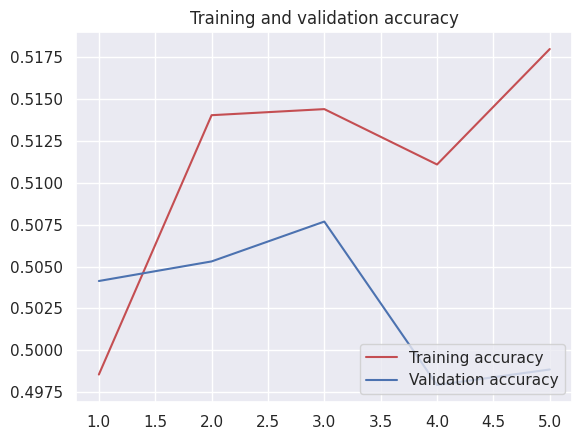

In [14]:
from numpy import e
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

acc=hist.history['accuracy']
val_acc=hist.history['val_accuracy']
epochs=range(1, len(acc)+1)

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.plot()

#GRU for text classification

In [15]:
model_gru = Sequential()
model_gru.add(InputLayer(shape=(1,), dtype=tf.string))
model_gru.add(TextVectorization(max_tokens=max_words, output_sequence_length=max_length))
model_gru.add(Embedding(max_words, 32))
model_gru.add(GRU(32))          # ← seul changement
model_gru.add(Dense(1, activation='sigmoid'))

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,369 (1.24 MB)

 Trainable params: 326,369 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
hist = model_lstm.fit(tf.constant(x), y, validation_split=0.5, epochs=5, batch_size=250)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 698ms/step - accuracy: 0.5302 - loss: 0.6817 - val_accuracy: 0.5017 - val_loss: 0.6943
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 714ms/step - accuracy: 0.5291 - loss: 0.6718 - val_accuracy: 0.5043 - val_loss: 0.7024
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 685ms/step - accuracy: 0.5339 - loss: 0.6618 - val_accuracy: 0.5035 - val_loss: 0.7054
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 708ms/step - accuracy: 0.5394 - loss: 0.6511 - val_accuracy: 0.5036 - val_loss: 0.7225
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 67s 671ms/step - accuracy: 0.5357 - loss: 0.6454 - val_accuracy: 0.5026 - val_loss: 0.7437


[]

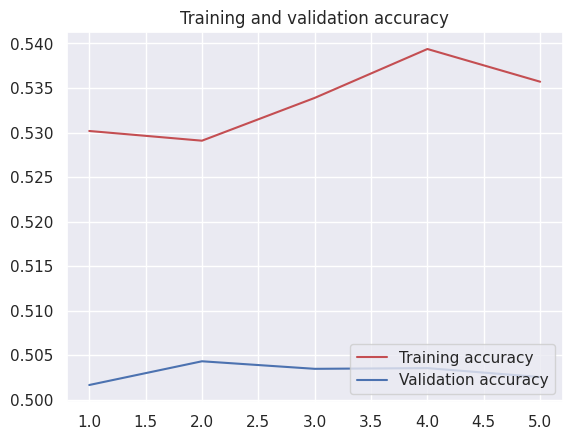

In [17]:
from numpy import e
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

acc=hist.history['accuracy']
val_acc=hist.history['val_accuracy']
epochs=range(1, len(acc)+1)

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='lower right')
plt.plot()

##Using Pretrained Models to Translate Text


In [19]:
!pip -q install transformers

In [25]:
from transformers import MarianMTModel, MarianTokenizer

# Name of the translation model (English -> French) from Helsinki-NLP
model_name = "Helsinki-NLP/opus-mt-en-fr"

# Load the tokenizer: converts raw text into tokens the model can understand
tokenizer = MarianTokenizer.from_pretrained(model_name)

# Load the pre-trained translation model
model = MarianMTModel.from_pretrained(model_name)

# Text to translate
text = "I love Emmanuella in The Name Of Jesus-Christ"

# Tokenize the input text:
# - [text] : wrap in a list because the model expects a batch
# - return_tensors="pt" : return PyTorch tensors
# - padding=True : pad sequences to the same length if multiple sentences
# - truncation=True : cut off text that exceeds the model's max input length
inputs = tokenizer([text], return_tensors="pt", padding=True, truncation=True)

# Generate the translation from the tokenized input
translated = model.generate(**inputs)

# Decode the output: convert token IDs back into human-readable text
# - skip_special_tokens=True : remove special tokens like [PAD], [EOS], etc.
result = tokenizer.decode(translated[0], skip_special_tokens=True)

# Print the translated text
print(result)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

J'aime Emmanuella au nom de Jésus-Christ
